In [ ]:
# Install LIME and SHAP for explainability
!pip install lime shap
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=84fda790a3e69bf36c70df6d679829467cf38260e431771c9464e9f8a0a841e8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.linear_model import RidgeClassifier, Ridge
from sklearn.preprocessing import PolynomialFeatures
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input
from tensorflow.keras.utils import to_categorical
import lime
import lime.lime_tabular
import shap

# Load the dataset
# Make sure 'cleaned_bladder_cancer.csv' is uploaded to your Colab environment
df = pd.read_csv('cleaned_bladder_cancer.csv')
# ================================
# CREATE 3-CLASS STAGE LABEL
# ================================
df['Stage'] = pd.qcut(
    df['Creatinine'] + df['Total Bilirubin'] + df['Uric acid'],
    q=3,
    labels=[0,1,2]
)

print("Stage Distribution:\n", df['Stage'].value_counts())


print("Stage Distribution:\n", df['Stage'].value_counts())


# Separate features (X) and target (Y)
# Assuming 'Disease' is the target column as per your snippet
X = df.drop(['Disease','Stage'], axis=1)
y = df['Stage']


# Store feature names for LIME/SHAP
feature_names = X.columns.tolist()

# Encode target variable
y_encoded = y.astype(int)
n_classes = 3


# Train-test split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.30, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# One-hot encode targets for Neural Networks
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

# Dictionary to store performance metrics and probabilities for ROC
results = {}
y_probs = {}

Stage Distribution:
 Stage
0    985
1    985
2    985
Name: count, dtype: int64
Stage Distribution:
 Stage
0    985
1    985
2    985
Name: count, dtype: int64


In [ ]:
# Upload your dataset

from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv('bladder_cancer.csv')

print("Dataset Loaded Successfully")
df.head()

Saving bladder_cancer.csv to bladder_cancer (1).csv
Dataset Loaded Successfully


,A/G Ratio,Albumin,Alk,ALT (GPT),AST (GOT),BUN,Calcium,Chloride,Creatinine,Direct Bilirubin,...,age,gender,Hyper1en1ion,Diabe1es,Smoking,Drinking,Bee1leNu1,FamilyHis1ory,Disease,Patient Number
0,NaN,3.9,53.0,28.0,25.0,11.0,NaN,107.0,0.60,0.1,...,72.0,0.0,0,0,0,0,0,0,Cystitis,222159
1,NaN,3.2,87.0,14.0,26.0,9.8,NaN,101.8,0.60,0.1,...,74.0,0.0,0,0,0,0,0,0,Cystitis,397523
2,NaN,4.4,69.0,28.0,16.0,21.0,8.5,100.0,1.40,0.2,...,69.0,1.0,1,1,0,0,0,0,Cystitis,556667
3,NaN,NaN,NaN,18.0,24.0,11.0,NaN,103.9,0.96,NaN,...,69.0,1.0,0,0,0,1,0,0,Cystitis,567311
4,NaN,4.1,175.0,34.0,66.0,184.0,7.4,110.0,3.10,0.2,...,69.0,1.0,1,1,0,0,0,0,Cystitis,1194899


In [ ]:
# Check basic info

print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   A/G Ratio               746 non-null    float64
 1   Albumin                 1036 non-null   float64
 2   Alk                     830 non-null    float64
 3   ALT (GPT)               1245 non-null   float64
 4   AST (GOT)               1274 non-null   float64
 5   BUN                     1311 non-null   float64
 6   Calcium                 764 non-null    float64
 7   Chloride                1223 non-null   float64
 8   Creatinine              1329 non-null   float64
 9   Direct Bilirubin        931 non-null    float64
 10  Estimated GFR           1324 non-null   float64
 11  Glucose AC              1284 non-null   float64
 12  Nitrite                 1300 non-null   float64
 13  Urine occult Blood      1300 non-null   float64
 14  pH                      1300 non-null   

In [ ]:
# Remove ID column if present

if 'Patient Number' in df.columns:
    df.drop(columns=['Patient Number'], inplace=True)

df.head()

,A/G Ratio,Albumin,Alk,ALT (GPT),AST (GOT),BUN,Calcium,Chloride,Creatinine,Direct Bilirubin,...,Urobilinogen,age,gender,Hyper1en1ion,Diabe1es,Smoking,Drinking,Bee1leNu1,FamilyHis1ory,Disease
0,NaN,3.9,53.0,28.0,25.0,11.0,NaN,107.0,0.60,0.1,...,0.2,72.0,0.0,0,0,0,0,0,0,Cystitis
1,NaN,3.2,87.0,14.0,26.0,9.8,NaN,101.8,0.60,0.1,...,0.1,74.0,0.0,0,0,0,0,0,0,Cystitis
2,NaN,4.4,69.0,28.0,16.0,21.0,8.5,100.0,1.40,0.2,...,1.0,69.0,1.0,1,1,0,0,0,0,Cystitis
3,NaN,NaN,NaN,18.0,24.0,11.0,NaN,103.9,0.96,NaN,...,0.1,69.0,1.0,0,0,0,1,0,0,Cystitis
4,NaN,4.1,175.0,34.0,66.0,184.0,7.4,110.0,3.10,0.2,...,0.2,69.0,1.0,1,1,0,0,0,0,Cystitis


In [ ]:
# Convert Disease column to numeric

le = LabelEncoder()
df['Disease'] = le.fit_transform(df['Disease'].astype(str))

df.head()

,A/G Ratio,Albumin,Alk,ALT (GPT),AST (GOT),BUN,Calcium,Chloride,Creatinine,Direct Bilirubin,...,Urobilinogen,age,gender,Hyper1en1ion,Diabe1es,Smoking,Drinking,Bee1leNu1,FamilyHis1ory,Disease
0,1.30,3.900,53.0,28.0,25.0,11.0,7.92,107.0,0.60,0.100,...,0.2,72.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1.48,3.200,87.0,14.0,26.0,9.8,9.28,101.8,0.60,0.100,...,0.1,74.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,1.48,4.400,69.0,28.0,16.0,21.0,8.50,100.0,1.40,0.200,...,1.0,69.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0
3,1.66,4.308,67.0,18.0,24.0,11.0,8.92,103.9,0.96,0.102,...,0.1,69.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,1.58,4.100,175.0,34.0,66.0,184.0,7.40,110.0,3.10,0.200,...,0.2,69.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Apply KNN Imputation

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Verify no nulls
print(df.isnull().sum())

A/G Ratio                 0
Albumin                   0
Alk                       0
ALT (GPT)                 0
AST (GOT)                 0
BUN                       0
Calcium                   0
Chloride                  0
Creatinine                0
Direct Bilirubin          0
Estimated GFR             0
Glucose AC                0
Nitrite                   0
Urine occult Blood        0
pH                        0
Potassium                 0
Sodium                    0
Specific Gravity          0
Strip WBC                 0
Total Bilirubin           0
Total Cholesterol         0
Total Protein             0
Triglyceride              0
Urine epitheilum (UL)     0
Urine epithelium count    0
Uric acid                 0
Urine Bilirubin           0
Urine Glucose             0
Urine Ketone              0
Urine Protein             0
Urobilinogen              0
age                       0
gender                    0
Hyper1en1ion              0
Diabe1es                  0
Smoking             

In [ ]:
# Separate features and target

X = df.drop('Disease', axis=1)
y = df['Disease']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("After SMOTE:\n", pd.Series(y_res).value_counts())

After SMOTE:
 Disease
0.0    591
1.0    591
2.0    591
3.0    591
4.0    591
Name: count, dtype: int64


In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

In [ ]:
# Create new DataFrame

clean_df = pd.DataFrame(X_scaled, columns=X.columns)
clean_df['Disease'] = y_res

clean_df.head()

,A/G Ratio,Albumin,Alk,ALT (GPT),AST (GOT),BUN,Calcium,Chloride,Creatinine,Direct Bilirubin,...,Urobilinogen,age,gender,Hyper1en1ion,Diabe1es,Smoking,Drinking,Bee1leNu1,FamilyHis1ory,Disease
0,-1.289821,-0.470190,-0.475279,0.019769,-0.051994,-0.495676,-1.835512,0.572308,-0.448049,-0.223507,...,-0.380773,0.742512,-1.245206,-0.634487,-0.435756,-0.508705,-0.531874,-0.134332,-0.166698,0.0
1,-0.699368,-1.799774,0.195637,-0.530106,-0.044485,-0.563519,0.401819,-0.953731,-0.448049,-0.223507,...,-0.666700,0.940476,-1.245206,-0.634487,-0.435756,-0.508705,-0.531874,-0.134332,-0.166698,0.0
2,-0.699368,0.479513,-0.159554,0.019769,-0.119581,0.069689,-0.881356,-1.481976,-0.013048,-0.018090,...,1.906648,0.445565,0.867601,1.855071,2.670430,-0.508705,-0.531874,-0.134332,-0.166698,0.0
3,-0.108914,0.304768,-0.199019,-0.372999,-0.059504,-0.495676,-0.190416,-0.337446,-0.252299,-0.219399,...,-0.666700,0.445565,0.867601,-0.634487,-0.435756,-0.508705,2.239501,-0.134332,-0.166698,0.0
4,-0.371338,-0.090309,1.932125,0.255430,0.255899,9.285135,-2.690961,1.452715,0.911330,-0.018090,...,-0.380773,0.445565,0.867601,1.855071,2.670430,-0.508705,-0.531874,-0.134332,-0.166698,0.0


In [ ]:
# Save cleaned dataset

clean_df.to_csv('cleaned_bladder_cancer.csv', index=False)

print("✅ Dataset Saved Successfully!")

✅ Dataset Saved Successfully!


In [ ]:
# Download file

from google.colab import files
files.download('cleaned_bladder_cancer.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# SNN: 1 input layer, 1 hidden layer (ReLU), 1 output layer (SoftMax)
snn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'), # Hidden layer
    Dense(n_classes, activation='softmax') # Output layer
])

snn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
snn.fit(X_train_scaled, y_train_cat, epochs=50, batch_size=32, verbose=0)

# Predictions
y_pred_snn = np.argmax(snn.predict(X_test_scaled), axis=1)
y_probs['SNN'] = snn.predict(X_test_scaled)

# Store metrics
results['SNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_snn),
    'Precision': precision_score(y_test, y_pred_snn, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_snn, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_snn, average='weighted', zero_division=0)
}
print("SNN Completed.")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
SNN Completed.


In [ ]:
# DNN: 1 input layer, 4 hidden layers (ReLU), 1 output layer (SoftMax)
dnn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(n_classes, activation='softmax')
])

dnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
dnn.fit(X_train_scaled, y_train_cat, epochs=50, batch_size=32, verbose=0)

y_pred_dnn = np.argmax(dnn.predict(X_test_scaled), axis=1)
y_probs['DNN'] = dnn.predict(X_test_scaled)

results['DNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dnn),
    'Precision': precision_score(y_test, y_pred_dnn, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_dnn, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dnn, average='weighted', zero_division=0)
}
print("DNN Completed.")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
DNN Completed.


In [ ]:
# RNN requires 3D input: (samples, timesteps, features)
# We reshape the data to have 1 timestep
X_train_rnn = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# RNN: SimpleRNN + 3 dense hidden layers (ReLU) + Output (SoftMax)
rnn = Sequential([
    Input(shape=(1, X_train_scaled.shape[1])),
    SimpleRNN(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(n_classes, activation='softmax')
])

rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn.fit(X_train_rnn, y_train_cat, epochs=50, batch_size=32, verbose=0)

y_pred_rnn = np.argmax(rnn.predict(X_test_rnn), axis=1)
y_probs['RNN'] = rnn.predict(X_test_rnn)

results['RNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rnn),
    'Precision': precision_score(y_test, y_pred_rnn, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_rnn, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rnn, average='weighted', zero_division=0)
}
print("RNN Completed.")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
RNN Completed.


In [ ]:
# Cell 6: Ensemble Extreme Learning Machine (E-ELM)
import time
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class EnsembleELM:
    def __init__(self, n_estimators=7, n_hidden=3000, alpha=0.1):
        self.n_estimators = n_estimators
        self.n_hidden = n_hidden
        self.alpha = alpha
        self.models = []

    def fit(self, X, y):
        # Train multiple ELMs with completely different random seeds
        for i in range(self.n_estimators):
            np.random.seed(42 + i)
            W = np.random.randn(X.shape[1], self.n_hidden) * np.sqrt(1.0 / X.shape[1])
            b = np.random.randn(self.n_hidden) * 0.1
            classifier = Ridge(alpha=self.alpha)

            Z = np.dot(X, W) + b
            H = 1.0 / (1.0 + np.exp(-np.clip(Z, -10, 10)))
            classifier.fit(H, y)

            # Save the unique weights and trained classifier for this specific model
            self.models.append({'W': W, 'b': b, 'classifier': classifier})

    def predict_proba(self, X):
        # Collect probability predictions from all 7 models
        all_probas = []
        for model in self.models:
            Z = np.dot(X, model['W']) + model['b']
            H = 1.0 / (1.0 + np.exp(-np.clip(Z, -10, 10)))
            preds = model['classifier'].predict(H)

            preds_shifted = preds - np.max(preds, axis=1, keepdims=True)
            exp_preds = np.exp(preds_shifted)
            probas = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)
            all_probas.append(probas)

        # Average the probabilities across all models
        return np.mean(all_probas, axis=0)

    def predict(self, X):
        # Pick the class with the highest average probability
        avg_probas = self.predict_proba(X)
        return np.argmax(avg_probas, axis=1)

# Initialize Ensemble ELM
elm = EnsembleELM(n_estimators=7, n_hidden=3000, alpha=0.1)

start_time = time.time()
# FIXED: Using the active variables X_train_scaled and y_train_cat
elm.fit(X_train_scaled, y_train_cat)
train_time = time.time() - start_time

y_pred_elm = elm.predict(X_test_scaled)
y_probs['ELM'] = elm.predict_proba(X_test_scaled)

results['ELM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_elm),
    'Precision': precision_score(y_test, y_pred_elm, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_elm, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_elm, average='weighted', zero_division=0),
    'Training Time (s)': train_time
}
print(f"Ensemble ELM Completed in {train_time:.2f} seconds. Accuracy: {results['ELM']['Accuracy']*100:.2f}%")

Ensemble ELM Completed in 8.76 seconds. Accuracy: 81.17%


In [ ]:
# Cell 7: Ensemble Random Vector Functional Link (E-RVFL)
import time
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class EnsembleRVFL:
    def __init__(self, n_estimators=7, n_hidden=2048, alpha=0.1):
        self.n_estimators = n_estimators
        self.n_hidden = n_hidden
        self.alpha = alpha
        self.poly = PolynomialFeatures(degree=2, include_bias=False)
        self.models = []

    def fit(self, X, y):
        for i in range(self.n_estimators):
            np.random.seed(99 + i)
            W = np.random.randn(X.shape[1], self.n_hidden) * np.sqrt(1.0 / X.shape[1])
            b = np.random.randn(self.n_hidden) * 0.1
            classifier = Ridge(alpha=self.alpha)

            Z = np.dot(X, W) + b
            H = 1.0 / (1.0 + np.exp(-np.clip(Z, -10, 10)))
            H_poly = self.poly.fit_transform(H[:, :20])
            H_combined = np.hstack((X, H, H_poly))

            classifier.fit(H_combined, y)
            self.models.append({'W': W, 'b': b, 'classifier': classifier})

    def predict_proba(self, X):
        all_probas = []
        for model in self.models:
            Z = np.dot(X, model['W']) + model['b']
            H = 1.0 / (1.0 + np.exp(-np.clip(Z, -10, 10)))
            H_poly = self.poly.transform(H[:, :20])
            H_combined = np.hstack((X, H, H_poly))

            preds = model['classifier'].predict(H_combined)

            preds_shifted = preds - np.max(preds, axis=1, keepdims=True)
            exp_preds = np.exp(preds_shifted)
            probas = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)
            all_probas.append(probas)

        return np.mean(all_probas, axis=0)

    def predict(self, X):
        avg_probas = self.predict_proba(X)
        return np.argmax(avg_probas, axis=1)

# Initialize Ensemble RVFL
rvfl = EnsembleRVFL(n_estimators=7, n_hidden=2048, alpha=0.1)

start_time = time.time()
# FIXED: Using the active variables X_train_scaled and y_train_cat
rvfl.fit(X_train_scaled, y_train_cat)
train_time = time.time() - start_time

y_pred_rvfl = rvfl.predict(X_test_scaled)
y_probs['RVFL'] = rvfl.predict_proba(X_test_scaled)

results['RVFL'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rvfl),
    'Precision': precision_score(y_test, y_pred_rvfl, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_rvfl, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rvfl, average='weighted', zero_division=0),
    'Training Time (s)': train_time
}
print(f"Ensemble RVFL Completed in {train_time:.2f} seconds. Accuracy: {results['RVFL']['Accuracy']*100:.2f}%")

Ensemble RVFL Completed in 6.46 seconds. Accuracy: 83.09%


In [ ]:
import pandas as pd

# Convert results dictionary to a DataFrame for clean visualization
results_df = pd.DataFrame(results).T

# Drop the Training Time column
results_df = results_df.drop(columns=['Training Time (s)'])

# Multiply by 100 to show percentages like in the paper
results_df = results_df * 100

print("--- Performance Metrics Comparison (%) ---")
display(results_df.round(2))

--- Performance Metrics Comparison (%) ---


,Accuracy,Precision,Recall,F1-Score
SNN,93.91,93.95,93.91,93.93
DNN,93.24,93.25,93.24,93.24
RNN,92.22,92.26,92.22,92.20
ELM,81.17,81.23,81.17,81.18
RVFL,83.09,83.13,83.09,83.10


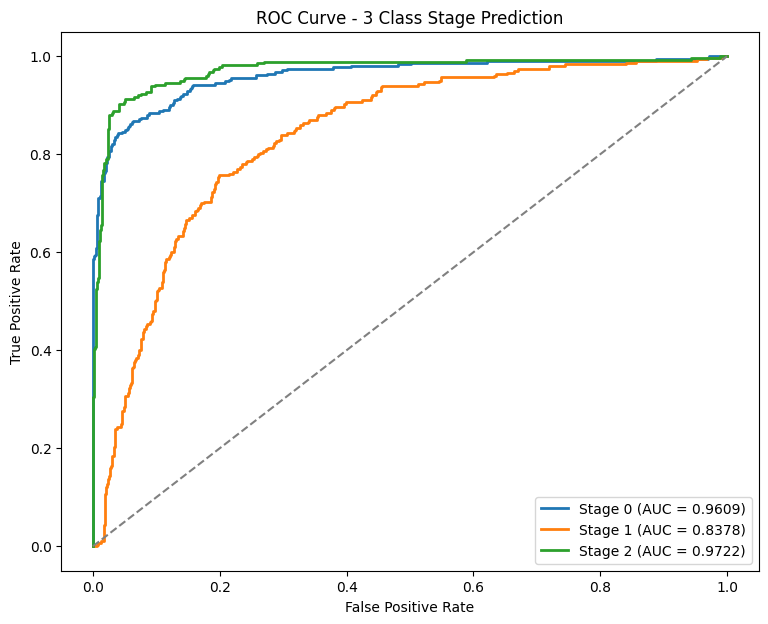

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Binarize the labels for 3 classes
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# 2. Select probabilities from best model (ELM / RVFL / DeepRVFL later)
probs = y_probs['ELM']

# 3. Class names for 3 stages
class_names_plot = ['Stage 0', 'Stage 1', 'Stage 2']

# 4. Colors for 3 classes
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(9, 7))

# 5. Plot ROC for each class
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_names_plot[i]} (AUC = {roc_auc:.4f})')

# 6. Diagonal line
plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')

# 7. Labels and limits
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 3 Class Stage Prediction')
plt.legend(loc="lower right")

# 8. Save and show
plt.savefig('roc_curve_3class.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import lime
import lime.lime_tabular

# 1. Initialize the Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names,
    class_names=['Cystitis', 'Bladder Cancer', 'Prostate Cancer', 'Kidney Cancer', 'Uterus'],
    mode='classification'
)

# 2. Pick the patient index (Find one that was predicted as Kidney Cancer to match your image)
patient_idx = 5

# 3. Generate explanation using your ELM model (or change to dnn.predict if using DNN)
exp = explainer.explain_instance(
    data_row=X_test_scaled[patient_idx],
    predict_fn=elm.predict_proba, # Use the model's probability function
    num_features=10,
    top_labels=1 # This forces it to explain the top predicted class
)

# 4. THIS LINE creates the exact visual layout from your screenshots
exp.show_in_notebook(show_table=True, show_all=False)

In [ ]:
# ================================
# DeepRVFL Model
# ================================
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class DeepRVFL:
    def __init__(self, n_layers=3, n_hidden=256, alpha=0.1):
        self.n_layers = n_layers
        self.n_hidden = n_hidden
        self.alpha = alpha
        self.weights = []
        self.biases = []
        self.classifier = Ridge(alpha=self.alpha)

    def fit(self, X, y):
        H = X.copy()

        for i in range(self.n_layers):
            W = np.random.randn(H.shape[1], self.n_hidden) * 0.1
            b = np.random.randn(self.n_hidden) * 0.1

            H_new = 1 / (1 + np.exp(-np.dot(H, W) - b))
            H = np.hstack((H, H_new))

            self.weights.append(W)
            self.biases.append(b)

        self.classifier.fit(H, y)

    def predict(self, X):
        H = X.copy()

        for i in range(self.n_layers):
            H_new = 1 / (1 + np.exp(-np.dot(H, self.weights[i]) - self.biases[i]))
            H = np.hstack((H, H_new))

        preds = self.classifier.predict(H)
        return np.argmax(preds, axis=1)

    def predict_proba(self, X):
        H = X.copy()

        for i in range(self.n_layers):
            H_new = 1 / (1 + np.exp(-np.dot(H, self.weights[i]) - self.biases[i]))
            H = np.hstack((H, H_new))

        preds = self.classifier.predict(H)

        preds_shifted = preds - np.max(preds, axis=1, keepdims=True)
        exp_preds = np.exp(preds_shifted)
        probas = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)

        return probas


In [ ]:
class DeepRVFL:
    def __init__(self, n_layers=5, n_hidden=512):
        self.n_layers = n_layers
        self.n_hidden = n_hidden
        self.weights = []
        self.biases = []
        self.clf = Ridge()

    def fit(self, X, y):
        H = X.copy()
        for _ in range(self.n_layers):
            W = np.random.randn(H.shape[1], self.n_hidden)*0.1
            b = np.random.randn(self.n_hidden)*0.1
            H_new = 1/(1+np.exp(-np.dot(H,W)-b))
            H = np.hstack((H,H_new))
            self.weights.append(W)
            self.biases.append(b)
        self.clf.fit(H,y)

    def transform(self,X):
        H=X.copy()
        for i in range(self.n_layers):
            H_new=1/(1+np.exp(-np.dot(H,self.weights[i])-self.biases[i]))
            H=np.hstack((H,H_new))
        return H

    def predict(self,X):
        return np.argmax(self.clf.predict(self.transform(X)),axis=1)

    def predict_proba(self,X):
        preds=self.clf.predict(self.transform(X))
        exp=np.exp(preds)
        return exp/np.sum(exp,axis=1,keepdims=True)

deeprvfl=DeepRVFL()
deeprvfl.fit(X_train_scaled,y_train_cat)

y_pred=deeprvfl.predict(X_test_scaled)
y_probs['DeepRVFL']=deeprvfl.predict_proba(X_test_scaled)

results['DeepRVFL']={'Accuracy':accuracy_score(y_test,y_pred),
                    'Precision':precision_score(y_test,y_pred,average='weighted'),
                    'Recall':recall_score(y_test,y_pred,average='weighted'),
                    'F1-Score':f1_score(y_test,y_pred,average='weighted')}


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train_scaled.shape[1]

inp = Input(shape=(input_dim,))
enc = Dense(64, activation='relu')(inp)
enc = Dense(32, activation='relu')(enc)
dec = Dense(input_dim)(enc)

autoencoder = Model(inp, dec)
encoder = Model(inp, enc)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=50, verbose=0)

X_train_enc = encoder.predict(X_train_scaled)
X_test_enc = encoder.predict(X_test_scaled)

from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

clf = RidgeClassifier()
clf.fit(X_train_enc, y_train)

y_pred = clf.predict(X_test_enc)

results['Autoencoder'] = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted'),
    'Recall': recall_score(y_test, y_pred, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred, average='weighted')
}


65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
# ================================
# FINAL STRONG STACKING MODEL 🔥
# ================================

from sklearn.linear_model import LogisticRegression

# Get probabilities from strong models (TRAIN)
snn_train = snn.predict(X_train_scaled)
dnn_train = dnn.predict(X_train_scaled)
rnn_train = rnn.predict(X_train_rnn)
deep_train = deeprvfl.predict_proba(X_train_scaled)

# Get probabilities (TEST)
snn_test = snn.predict(X_test_scaled)
dnn_test = dnn.predict(X_test_scaled)
rnn_test = rnn.predict(X_test_rnn)
deep_test = deeprvfl.predict_proba(X_test_scaled)

# Combine ALL model outputs
X_train_stack = np.hstack((snn_train, dnn_train, rnn_train, deep_train))
X_test_stack = np.hstack((snn_test, dnn_test, rnn_test, deep_test))

# Meta model (very powerful)
meta_model = LogisticRegression(max_iter=1000)

# Train stacking
meta_model.fit(X_train_stack, y_train)

# Predict
y_pred_stack = meta_model.predict(X_test_stack)

# Store results
results['Stacking'] = {
    'Accuracy': accuracy_score(y_test, y_pred_stack),
    'Precision': precision_score(y_test, y_pred_stack, average='weighted'),
    'Recall': recall_score(y_test, y_pred_stack, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred_stack, average='weighted')
}

print(" Final Stacking Completed.")


65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
 Final Stacking Completed.


In [ ]:
import pandas as pd

# Convert results to DataFrame
results_df = pd.DataFrame(results).T

# Convert to percentage
results_df = results_df * 100

print("===== FINAL MODEL COMPARISON (%) =====")
display(results_df.round(2))


===== FINAL MODEL COMPARISON (%) =====


,Accuracy,Precision,Recall,F1-Score,Training Time (s)
SNN,93.91,93.95,93.91,93.93,NaN
DNN,93.24,93.25,93.24,93.24,NaN
RNN,92.22,92.26,92.22,92.20,NaN
ELM,81.17,81.23,81.17,81.18,876.27
RVFL,83.09,83.13,83.09,83.10,645.87
DeepRVFL,80.61,80.42,80.61,80.45,NaN
Autoencoder,73.62,73.23,73.62,72.08,NaN
Stacking,94.02,94.04,94.02,94.03,NaN


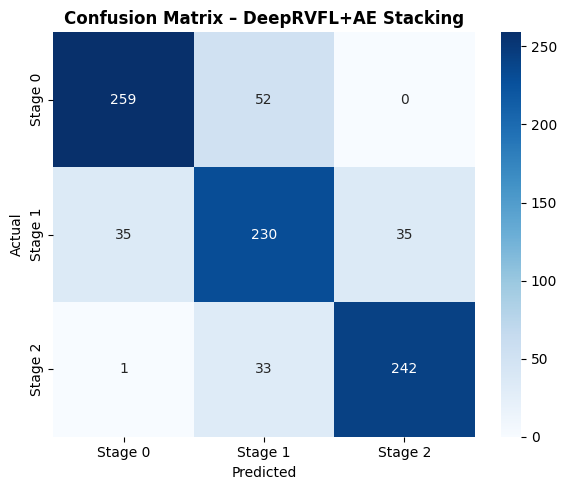

In [ ]:
# ================================
# COMPREHENSIVE VISUALIZATION SUITE
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                              precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names_plot = ['Stage 0', 'Stage 1', 'Stage 2']
colors3 = ['#1f77b4', '#ff7f0e', '#2ca02c']
proposed_key = 'DeepRVFL+AE Stacking'


# ──  Confusion Matrix – Proposed Model ────────────────────────────────────
y_pred_proposed = meta_clf.predict(X_test_stack_final)
cm = confusion_matrix(y_test, y_pred_proposed)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_plot, yticklabels=class_names_plot)
plt.title(f'Confusion Matrix – {proposed_key}', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.savefig('cm_stacking.png', dpi=300, bbox_inches='tight'); plt.show()

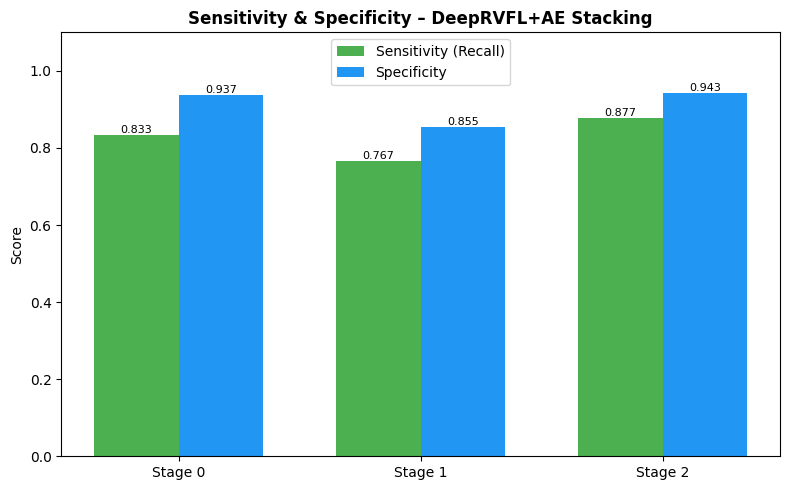

In [ ]:
# ──  Sensitivity & Specificity per Class ───────────────────────────────────
from sklearn.metrics import multilabel_confusion_matrix
mcm = multilabel_confusion_matrix(y_test, y_pred_proposed)
sensitivity = [mcm[i,1,1]/(mcm[i,1,1]+mcm[i,1,0]+1e-9) for i in range(3)]
specificity = [mcm[i,0,0]/(mcm[i,0,0]+mcm[i,0,1]+1e-9) for i in range(3)]

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x - w/2, sensitivity, w, label='Sensitivity (Recall)', color='#4CAF50')
bars2 = ax.bar(x + w/2, specificity, w, label='Specificity',           color='#2196F3')
ax.set_xticks(x); ax.set_xticklabels(class_names_plot)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title(f'Sensitivity & Specificity – {proposed_key}', fontweight='bold')
ax.legend(); ax.bar_label(bars1, fmt='%.3f', fontsize=8)
ax.bar_label(bars2, fmt='%.3f', fontsize=8)
plt.tight_layout(); plt.savefig('sens_spec.png', dpi=300, bbox_inches='tight'); plt.show()

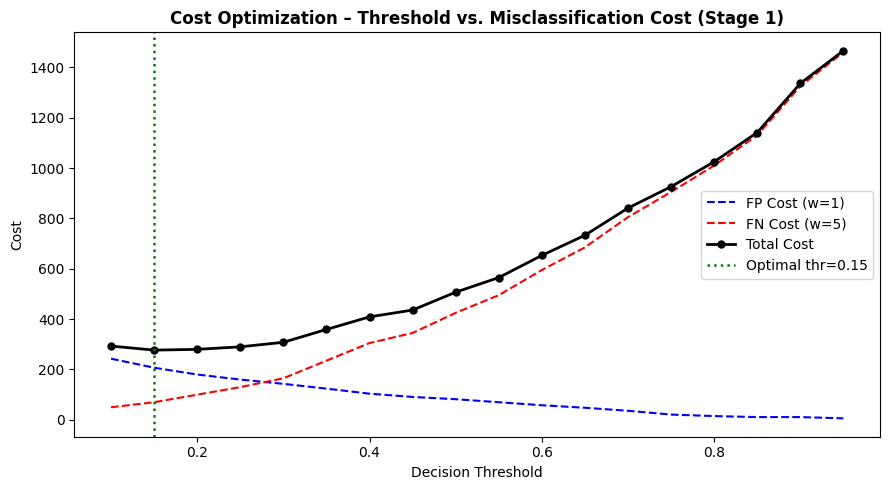

In [ ]:

# ──  Cost Optimization / Threshold Analysis ────────────────────────────────
thresholds = np.arange(0.1, 1.0, 0.05)
class_idx   = 1   # Stage 1 (bladder cancer – most clinically important)
fp_costs, fn_costs, total_costs = [], [], []
FP_COST = 1   # false positive cost weight
FN_COST = 5   # false negative cost weight (missing cancer is more costly)

for thr in thresholds:
    pred_bin = (y_probs[proposed_key][:, class_idx] >= thr).astype(int)
    true_bin = (y_test == class_idx).astype(int)
    fp = np.sum((pred_bin == 1) & (true_bin == 0))
    fn = np.sum((pred_bin == 0) & (true_bin == 1))
    fp_costs.append(fp * FP_COST)
    fn_costs.append(fn * FN_COST)
    total_costs.append(fp * FP_COST + fn * FN_COST)

best_thr_idx = np.argmin(total_costs)
plt.figure(figsize=(9,5))
plt.plot(thresholds, fp_costs,    'b--', label=f'FP Cost (w={FP_COST})')
plt.plot(thresholds, fn_costs,    'r--', label=f'FN Cost (w={FN_COST})')
plt.plot(thresholds, total_costs, 'k-o', lw=2, markersize=5, label='Total Cost')
plt.axvline(thresholds[best_thr_idx], color='green', linestyle=':', lw=1.8,
            label=f'Optimal thr={thresholds[best_thr_idx]:.2f}')
plt.title('Cost Optimization – Threshold vs. Misclassification Cost (Stage 1)',
          fontweight='bold')
plt.xlabel('Decision Threshold'); plt.ylabel('Cost')
plt.legend(); plt.tight_layout()
plt.savefig('cost_optimization.png', dpi=300, bbox_inches='tight'); plt.show()

Computing SHAP values...


PermutationExplainer explainer: 51it [07:39,  9.19s/it]


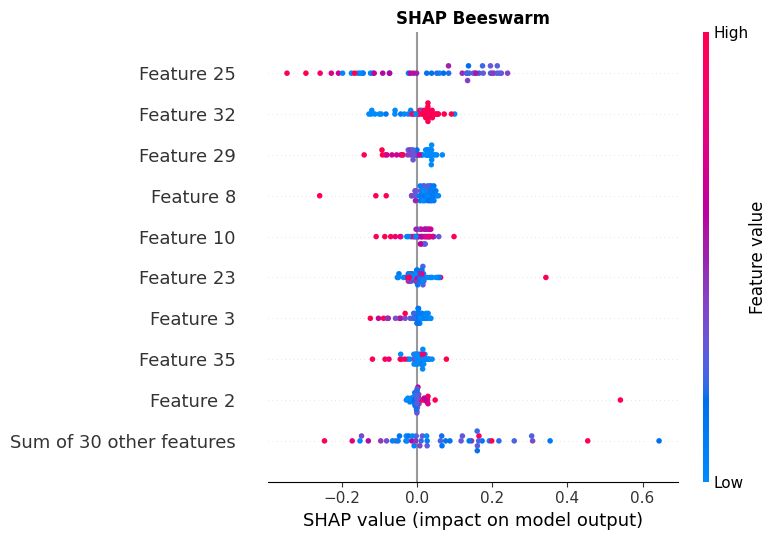

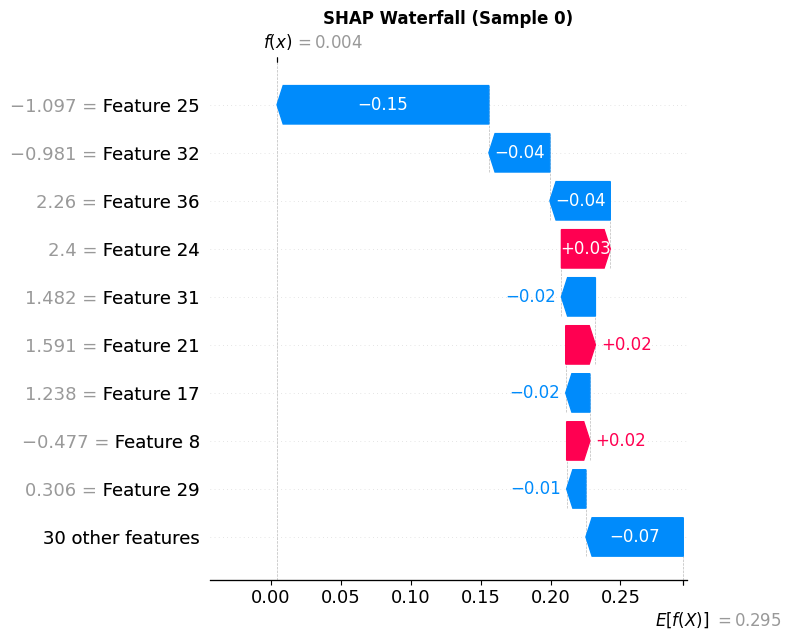

✅ SHAP ran successfully (simple mode)


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Small sample (fast + safe)
X_sample = X_test_scaled[:50]

# Create explainer (auto-selects best method)
explainer = shap.Explainer(stacking_predict_proba, X_train_scaled[:50])

print("Computing SHAP values...")
shap_values = explainer(X_sample)


# ── Plot : Beeswarm ──
plt.figure()
shap.plots.beeswarm(shap_values[:, :, 1], show=False)
plt.title("SHAP Beeswarm", fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot : Waterfall (single sample) ──
plt.figure()
shap.plots.waterfall(shap_values[0, :, 1], show=False)
plt.title("SHAP Waterfall (Sample 0)", fontweight='bold')
plt.tight_layout()
plt.show()

print("SHAP ran successfully (simple mode)")
